Some scratch cells for MAD-X to G4Beamline translation. I might organize this into something more formal later

In [2]:
from g4beam import *

In [36]:
# Generate a distribution for testing, matching the second 

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
write_trackfile(particles_before, "test_particles_before.txt")

In [28]:
particles_after_list = [read_trackfile(f"vd_{i}.txt") for i in range(5)]

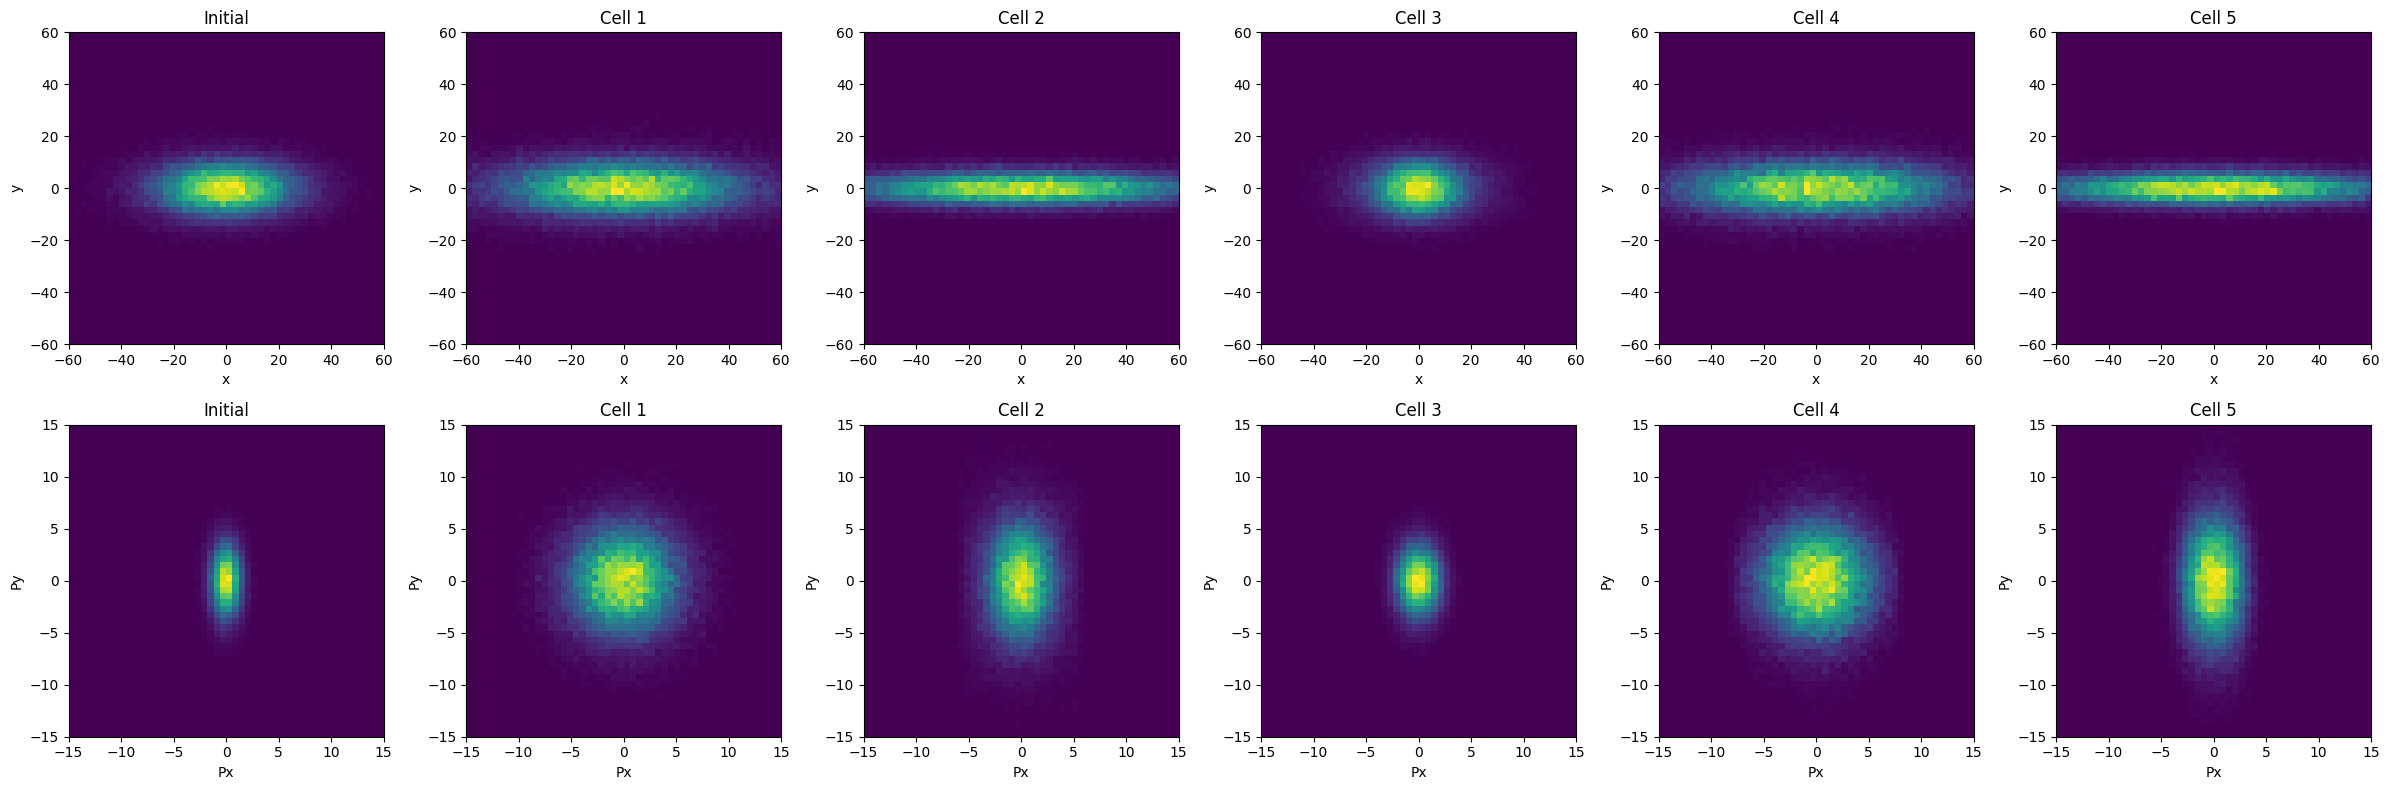

In [34]:
num_after = len(particles_after_list)
num_cols = num_after + 1  # One column for "before" and additional columns for each "after"
fig, axes = plt.subplots(2, num_cols, figsize=(4 * num_cols, 8))

x_range = [[-60, 60], [-60, 60]]
p_range = [[-15, 15], [-15, 15]]

# Plot "Before" data
axes[0, 0].hist2d(particles_before.x, particles_before.y, bins=50, range=x_range)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].set_title("Initial")

axes[1, 0].hist2d(particles_before.Px, particles_before.Py, bins=50, range=p_range)
axes[1, 0].set_xlabel("Px")
axes[1, 0].set_ylabel("Py")
axes[1, 0].set_title("Initial")

# Plot each "After" dataset
for i, particles_after in enumerate(particles_after_list):
    col = i + 1  # Column index shifts right
    axes[0, col].hist2d(particles_after.x, particles_after.y, bins=50, range=x_range)
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")
    axes[0, col].set_title(f"Cell {i+1}")

    axes[1, col].hist2d(particles_after.Px, particles_after.Py, bins=50, range=p_range)
    axes[1, col].set_xlabel("Px")
    axes[1, col].set_ylabel("Py")
    axes[1, col].set_title(f"Cell {i+1}")

plt.tight_layout()
plt.savefig("visuals/drift/test.png")
